<div>
<div style="font-size: 0.85em; letter-spacing: 0.08em; text-transform: uppercase; color: #1c4ed8; font-weight: 700; margin-bottom: 0.5em;">ML Research &middot; Customer Retention</div>
<h1 style="margin: 0 0 0.3em; font-weight: 800; letter-spacing: -0.01em;">From churn risk to retention decisions</h1>
<p style="margin-top: 0; font-size: 1.2em; color: #444;">Deciding each night which at-risk customers to contact, with which offer, within a fixed retention budget</p>
</div>

<div style="border: 2px solid #a94442; padding: 20px 30px;">
<h2>Disclosure</h2>
<ul style="margin-left: 0; padding-left: 1.25em;">
<li>All data and modeled results are synthetic. The approximately 105,000-account carrier, its 24 months of history, two past retention campaigns, and 6,000 care notes were generated and validated in <code>data/<wbr>00_generate_<wbr>and_validate_<wbr>data.ipynb</code>.</li>
<li>Plan names, prices, offers, and results are illustrative and do not describe any carrier.</li>
<li>The modeling notebooks read only tables a carrier could actually hold. The withheld answer key (each account's hidden reason for leaving, its true churn probabilities, and the months after the scoring date) is loaded only to score finished models.</li>
</ul>
</div>

<hr>
<div>
<h2>Introduction</h2>
<p><strong>Business Question:</strong> A carrier has a fixed monthly retention budget. Each night, which at-risk customers should it contact, with which offer, and what should the message say?</p>
<p><strong>Data and Scope:</strong> 24 months of history for about 105,000 accounts: bills, usage, dropped calls, care contacts with the rep's reason code, a randomized retention test of 40,000 accounts in month 13, a targeted campaign in month 19, and 6,000 care notes. Tonight's batch is the 75,301 accounts active at the end of month 24.</p>
<p><strong>Approach:</strong> Each question gets its own model, and plain code, not the language model, produces every number:</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Section</th><th style="text-align: left;">Question</th><th style="text-align: left;">Method</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">01 · Churn Timing</td><td style="text-align: left; vertical-align: top;">Who is likely to leave, and when?</td><td style="text-align: left; vertical-align: top;">Cox model and a gradient-boosted discrete-time hazard</td></tr>
<tr><td style="text-align: left; vertical-align: top;">02 · Offer Effect</td><td style="text-align: left; vertical-align: top;">Who would an offer actually keep?</td><td style="text-align: left; vertical-align: top;">Uplift models on the randomized test</td></tr>
<tr><td style="text-align: left; vertical-align: top;">03 · Churn Reasons</td><td style="text-align: left; vertical-align: top;">Why would they leave?</td><td style="text-align: left; vertical-align: top;">Embeddings and topic modeling on care notes</td></tr>
<tr><td style="text-align: left; vertical-align: top;">04 · Offer Optimizer</td><td style="text-align: left; vertical-align: top;">Whom to contact within the budget?</td><td style="text-align: left; vertical-align: top;">Budget-constrained selection on expected value</td></tr>
<tr><td style="text-align: left; vertical-align: top;">05 · Retention Agent</td><td style="text-align: left; vertical-align: top;">What should each message say, and is it allowed?</td><td style="text-align: left; vertical-align: top;">LangGraph agent with retrieval, drafting, a policy check, and human approval</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>Initialize Modeling Environment</h2>
<p>Initializes the shared imports, plotting style, and data access used throughout section 01. Tables load through <code>retention.data.load()</code>, which refuses answer-key tables, and features come from <code>retention.features</code>, which every later section and the agent's nightly run share.</p>
</div>

In [1]:
# Standard Library
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.metrics import brier_score_loss, roc_auc_score
from IPython.display import display

sys.path.insert(0, 'src')
from retention import data, features as F

warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
TEAL = '#1baf7a'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Output Helpers & Constants
OUTPUTS = Path('outputs')
OUTPUTS.mkdir(exist_ok = True)

SEED = 20260921
N_MONTHS = 24
BACKTEST_MONTH = 21
TRAINING_WINDOW = 12
HORIZONS = {1: 'p_churn_30', 2: 'p_churn_60', 3: 'p_churn_90'}


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>01 · Churn Timing</h1>
<p><strong>Purpose:</strong> Estimates each customer's probability of leaving within 30, 60, and 90 days, the risk half of the retention decision. Section 02 estimates the other half, whether an offer would change it.</p>
<p><strong>Architecture:</strong> Churn is observed monthly, so each account-month is a chance to leave the next month. Both models estimate that monthly hazard; rolling it forward three months, with tenure and the phone aging, gives the 30-, 60-, and 90-day probabilities.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Why</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1 · Survival data</td><td style="text-align: left; vertical-align: top;">Account-months with next-month churn, offer-affected months removed; Kaplan–Meier curves</td><td style="text-align: left; vertical-align: top;">Models must learn untreated churn</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2 · Cox baseline</td><td style="text-align: left; vertical-align: top;">Time-varying Cox proportional hazards on tenure</td><td style="text-align: left; vertical-align: top;">Interpretable hazard ratios</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3 · Gradient-boosted hazard</td><td style="text-align: left; vertical-align: top;">LightGBM on account-months</td><td style="text-align: left; vertical-align: top;">Non-linear effects and interactions</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4 · Backtest</td><td style="text-align: left; vertical-align: top;">Fit through month 20, score month 21, compare with months 22–24</td><td style="text-align: left; vertical-align: top;">Checks the models on observed data</td></tr>
<tr><td style="text-align: left; vertical-align: top;">5 · Tonight's batch</td><td style="text-align: left; vertical-align: top;">Score month 24 against the answer key</td><td style="text-align: left; vertical-align: top;">Measures how much of the true risk the models recover</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Survival Data</h2>
<p><strong>Purpose:</strong> Turns the monthly panel into account-months, each labeled with whether the account left the following month, and looks at how survival differs across simple groups before any model is fitted.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Features.</strong> Each row describes an account at the end of a month using that month and earlier: the month's bill, usage, dropped calls, and contacts; 3-month summaries; the rep's reason codes over 6 months; tenure; months since the phone was paid off; and plan, lines, autopay, and region.</li>
<li style="margin-bottom: 0.7em;"><strong>Offer-Affected Months Removed.</strong> An offer changes churn for the 6 months after it's made. Those account-months are dropped for the offered arms of both campaigns, so the models learn churn without an offer, the baseline that uplift is measured against.</li>
<li style="margin-bottom: 0.7em;"><strong>Kaplan–Meier Curves.</strong> Accounts active at month 1, followed for 24 months, by tenure band at month 1 and by whether they are in a weak-network region.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Churn drifts down over the history.</strong> About 1.8% of accounts left each month early on and about 1.2% by months 19–23, with a surge back to about 1.8% in months 15–17 during the competitor promotion. A model fitted on older months expects more churn than recent months deliver (section 4).</li>
<li style="margin-bottom: 0.7em;"><strong>Offer-affected months are a small share.</strong> 196,794 account-months fall inside an offer's effect window and are removed, leaving 1.6 million for training.</li>
<li style="margin-bottom: 0.7em;"><strong>Simple groups already separate.</strong> After 24 months, 66% of accounts under a year old at month 1 remain, against 72% of accounts with 3+ years. In the two weak-network regions 60% remain, against 74% elsewhere.</li>
</ol>
</div>

In [4]:
# Build Survival Data
panel = data.load('monthly_panel')
accounts = data.load('accounts')
contacts = data.load('care_contacts')
campaigns = data.load('campaigns')

account_months = F.build_features(panel, accounts, contacts)
offer_affected = F.offer_windows(campaigns).assign(offer_affected = True)
account_months = account_months.merge(offer_affected, on = ['account_id', 'month'], how = 'left')
account_months['offer_affected'] = account_months['offer_affected'].fillna(False).astype(bool)
labeled = account_months[account_months['left_next_month'].notna() & ~account_months['offer_affected']]

print(f'{len(account_months):,} account-months · {account_months["offer_affected"].sum():,} offer-affected, removed · '
      f'{len(labeled):,} labeled for training')
display(labeled.groupby('month')['left_next_month'].mean().mul(100).round(2).to_frame('% leaving next month').T)

1,867,578 account-months · 196,794 offer-affected, removed · 1,604,950 labeled for training


month,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
% leaving next month,1.83,1.86,1.78,1.58,1.6,1.56,1.54,1.53,1.43,1.44,1.53,1.46,1.42,1.32,1.86,1.83,1.78,1.28,1.17,1.21,1.16,1.21,1.27


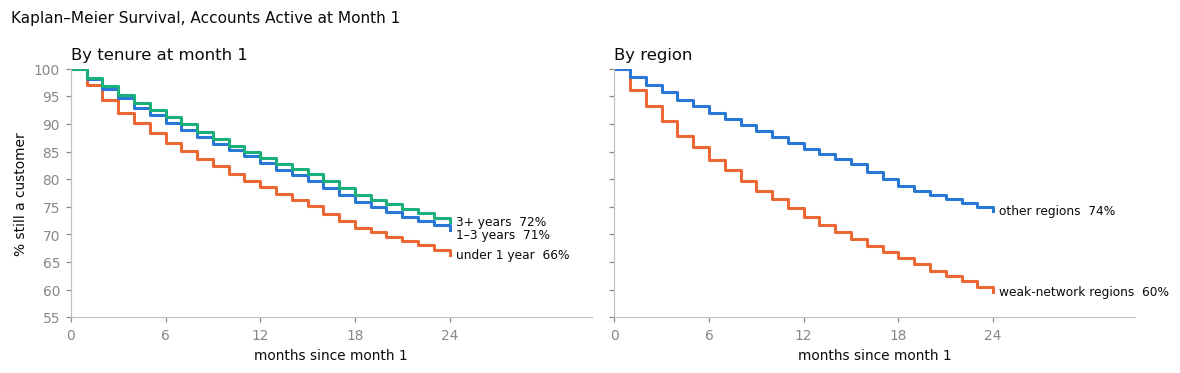

In [5]:
# Plot: Kaplan–Meier Survival Curves
start = panel[panel['month'] == 1].merge(accounts[['account_id', 'join_month', 'region_id']], on = 'account_id')
ends = panel.groupby('account_id').agg(last_month = ('month', 'max'), left = ('churned', 'any'))
start = start.join(ends, on = 'account_id')
start['months'] = start['last_month']
start['tenure_band'] = pd.cut(1 - start['join_month'], [-1, 11, 35, 999], labels = ['under 1 year', '1–3 years', '3+ years'])
start['network'] = np.where(start['region_id'].isin([2, 5]), 'weak-network regions', 'other regions')

fig, axes = plt.subplots(1, 2, figsize = (11, 3.4), sharey = True)
for ax, column, groups, colors in [
        (axes[0], 'tenure_band', ['under 1 year', '1–3 years', '3+ years'], [ACCENT2, ACCENT, TEAL]),
        (axes[1], 'network', ['weak-network regions', 'other regions'], [ACCENT2, ACCENT])]:
    ends_at = []
    for group, color in zip(groups, colors):
        g = start[start[column] == group]
        km = KaplanMeierFitter().fit(g['months'], g['left'])
        curve = km.survival_function_.iloc[:, 0] * 100
        ax.step(curve.index, curve.values, where = 'post', color = color, linewidth = 2)
        ends_at.append((curve.iloc[-1], group))
    placed = []
    for value, group in sorted(ends_at, reverse = True):
        y = min([value] + [p - 2.2 for p in placed])
        placed.append(y)
        ax.text(N_MONTHS + 0.4, y, f'{group}  {value:.0f}%', va = 'center', fontsize = 8, color = INK)
    ax.set_xlim(0, N_MONTHS + 9)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_xlabel('months since month 1')
axes[0].set_ylabel('% still a customer')
axes[0].set_ylim(55, 100)
axes[0].set_title('By tenure at month 1', loc = 'left')
axes[1].set_title('By region', loc = 'left')
fig.suptitle('Kaplan–Meier Survival, Accounts Active at Month 1', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>2 · Cox Baseline</h2>
<p><strong>Purpose:</strong> Fits a time-varying Cox proportional hazards model: an interpretable baseline whose hazard ratios say how much each factor raises or lowers the monthly chance of leaving.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Time Axis.</strong> Tenure, so the baseline hazard absorbs early-tenure churn. Each account-month is one interval, (tenure, tenure + 1], with that month's features.</li>
<li style="margin-bottom: 0.7em;"><strong>Covariates.</strong> A linear model needs the payoff effect spelled out: an indicator for the 4 months after payoff and months past the device term, plus 3-month summaries, reason codes, lines, autopay, and the 15 GB plan.</li>
<li style="margin-bottom: 0.7em;"><strong>Training Window.</strong> The last 12 labeled months, the same window as the gradient-boosted model. Churn levels drift over time, and a recent window tracks them better than the full history (section 4).</li>
<li style="margin-bottom: 0.7em;"><strong>Sample.</strong> 20,000 accounts, drawn at random; the Cox partial likelihood grows quickly with rows, and the hazard ratios are stable well before the full base.</li>
<li style="margin-bottom: 0.7em;"><strong>Probabilities.</strong> The baseline cumulative hazard between tenure t and t + k, scaled by the account's relative risk, gives its probability of leaving within k months.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Device payoff and moving stand out.</strong> In the 4 months after a phone is paid off, the monthly hazard is 1.59 times higher. Each account-change contact in the past 6 months, the code reps use for moves, raises it 1.52 times.</li>
<li style="margin-bottom: 0.7em;"><strong>Competitor promotions and dropped calls raise risk steadily.</strong> 1.18 times per point of the promotion index, and 1.13 times per percentage point of dropped calls.</li>
<li style="margin-bottom: 0.7em;"><strong>Two results are artifacts of a linear model.</strong> Bill increases aren't significant, and service contacts come out slightly protective (0.93). Bill increases matter only for price-sensitive customers under pressure, and service contacts overlap with the total contact count and unresolved tickets. The gradient-boosted model doesn't need these relationships spelled out.</li>
</ol>
</div>

In [6]:
# Fit Cox Baseline
COX_FIELDS = [
    'bill_change_max_3m', 'competitor_promo_max_3m', 'dropped_call_rate_3m', 'care_contacts_3m', 'unresolved_ticket',
    'late_payments_3m', 'throttle_days_3m', 'lines', 'autopay',
    'billing_contacts_6m', 'network_contacts_6m', 'device_contacts_6m', 'service_contacts_6m', 'account_contacts_6m',
]


def cox_frame(rows):

    X = rows[COX_FIELDS].astype(float).copy()
    X['just_paid_off'] = rows['months_since_payoff'].between(1, 4).astype(float)
    X['months_past_device_term'] = rows['months_since_payoff'].clip(0, 30).astype(float)
    X['plan_15gb'] = (rows['plan'] == '15gb').astype(float)

    return X


def fit_cox(train, n_accounts = 20_000):

    ids = np.random.default_rng(SEED).choice(train['account_id'].unique(), n_accounts, replace = False)
    rows = train[train['account_id'].isin(ids)]
    X = cox_frame(rows).assign(
        id = rows['account_id'].to_numpy(), start = rows['tenure'].to_numpy(dtype = float),
        event = rows['left_next_month'].to_numpy())
    X['stop'] = X['start'] + 1

    return CoxTimeVaryingFitter(penalizer = 0.01).fit(X, id_col = 'id', event_col = 'event', start_col = 'start', stop_col = 'stop')


def cox_probabilities(model, rows):

    baseline = model.baseline_cumulative_hazard_.iloc[:, 0]
    grid = np.arange(0, 200)
    cumulative = np.interp(grid, baseline.index.to_numpy(), baseline.to_numpy())
    relative_risk = model.predict_partial_hazard(cox_frame(rows)).to_numpy()
    tenure = rows['tenure'].clip(0, 190).to_numpy()

    return pd.DataFrame({
        name: 1 - np.exp(-(cumulative[tenure + k] - cumulative[tenure]) * relative_risk) for k, name in HORIZONS.items()
    }, index = rows.index)


def training_window(last_month):
    return labeled[labeled['month'].between(last_month - TRAINING_WINDOW + 1, last_month)]


cox = fit_cox(training_window(N_MONTHS - 1))
hazard_ratios = cox.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].sort_values('exp(coef)')
display(hazard_ratios.round(3))

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
service_contacts_6m,0.926,0.867,0.989,0.023
bill_change_max_3m,0.940,0.701,1.261,0.680
plan_15gb,0.984,0.913,1.060,0.672
late_payments_3m,0.984,0.899,1.077,0.728
device_contacts_6m,0.985,0.904,1.072,0.721
throttle_days_3m,0.996,0.990,1.001,0.137
lines,0.996,0.969,1.024,0.786
autopay,1.000,0.934,1.070,0.992
months_past_device_term,1.003,1.000,1.006,0.035


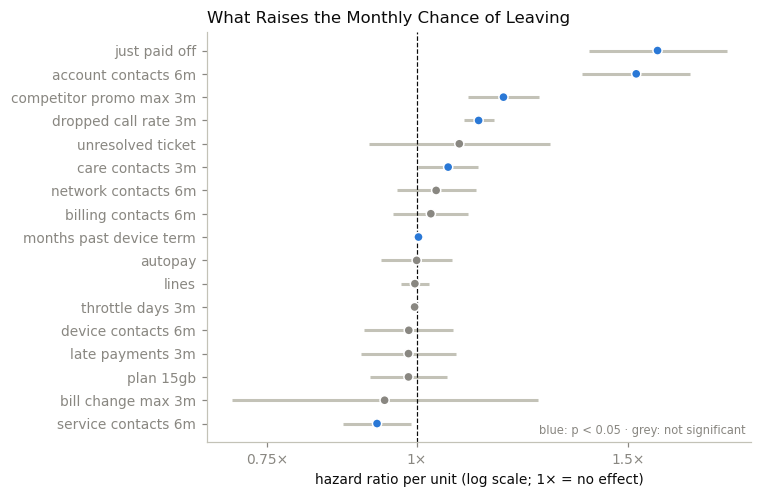

In [7]:
# Plot: Cox Hazard Ratios
fig, ax = plt.subplots(figsize = (7, 4.6))
y = np.arange(len(hazard_ratios))
significant = hazard_ratios['p'] < 0.05
ax.hlines(y, hazard_ratios['exp(coef) lower 95%'], hazard_ratios['exp(coef) upper 95%'], color = BASELINE, linewidth = 2)
ax.scatter(hazard_ratios['exp(coef)'], y, s = 36, color = np.where(significant, ACCENT, MUTED), edgecolor = SURFACE, linewidth = 1, zorder = 3)
ax.axvline(1, color = INK, linewidth = 0.8, linestyle = '--')
ax.set_yticks(y)
ax.set_yticklabels(hazard_ratios.index.str.replace('_', ' '))
ax.set_xscale('log')
ax.xaxis.set_major_locator(plt.FixedLocator([0.5, 0.75, 1, 1.5, 2]))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}×'))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel('hazard ratio per unit (log scale; 1× = no effect)')
ax.set_title('What Raises the Monthly Chance of Leaving', loc = 'left')
ax.text(0.99, 0.02, 'blue: p < 0.05 · grey: not significant', transform = ax.transAxes, ha = 'right', fontsize = 7.5, color = MUTED)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>3 · Gradient-Boosted Hazard</h2>
<p><strong>Purpose:</strong> Fits the same monthly hazard with gradient-boosted trees, which can find non-linear effects and interactions the Cox model has to be told about, such as the jump after payoff or dropped calls that only matter above a threshold.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model.</strong> LightGBM classifier on account-months: will this account leave next month? It uses every feature, including tenure and months since payoff, in raw form.</li>
<li style="margin-bottom: 0.7em;"><strong>Settings.</strong> 400 trees of 15 leaves, at least 500 account-months per leaf, learning rate 0.03. Churn is rare, about 1.2% a month, so large leaves keep the estimates stable; deeper and shallower settings scored no better on the backtest.</li>
<li style="margin-bottom: 0.7em;"><strong>Rolling Forward.</strong> Month-by-month hazards for the next 3 months come from the same features with tenure, phone age, and months to payoff advanced; everything else is held at its current value, since the carrier can't know next month's bill yet.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The same drivers, with more shape.</strong> Tenure, dropped calls, device age, and competitor promotions carry half the model's splitting gain: the drivers the Cox model found, plus tenure's non-linear curve.</li>
<li style="margin-bottom: 0.7em;"><strong>The rep's reason codes carry signal.</strong> Account-change and network codes rank highest among them. The care notes (section 03) should add more of this signal than the codes alone.</li>
</ol>
</div>

In [8]:
# Fit Gradient-Boosted Hazard
GBM_SETTINGS = dict(
    objective = 'binary', n_estimators = 400, learning_rate = 0.03, num_leaves = 15, min_child_samples = 500,
    subsample = 0.8, subsample_freq = 1, colsample_bytree = 0.8, reg_lambda = 1.0, random_state = SEED, verbose = -1)


def fit_gbm(train):
    return lgb.LGBMClassifier(**GBM_SETTINGS).fit(F.as_model_frame(train), train['left_next_month'].astype(int))


def gbm_probabilities(model, rows):

    monthly = np.column_stack([model.predict_proba(F.as_model_frame(F.age(rows, k)))[:, 1] for k in range(3)])
    survival = np.cumprod(1 - monthly, axis = 1)

    return pd.DataFrame({name: 1 - survival[:, k - 1] for k, name in HORIZONS.items()}, index = rows.index)


gbm = fit_gbm(training_window(N_MONTHS - 1))
importance = pd.Series(gbm.booster_.feature_importance('gain'), index = F.FEATURES)
importance = (importance / importance.sum()).sort_values(ascending = False)
display(importance.head(12).mul(100).round(1).to_frame('% of total gain'))

,% of total gain
tenure,15.3
dropped_call_rate_3m,10.7
device_age,9.8
competitor_promo,9.5
dropped_call_rate,6.4
bill_change,6.0
account_contacts_6m,5.3
network_contacts_6m,5.2
bill_change_max_3m,5.2
data_gb,5.1


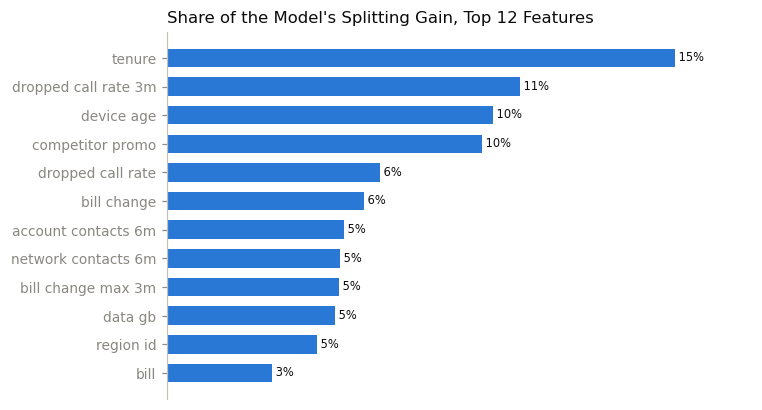

In [9]:
# Plot: Gradient-Boosted Feature Importance
top = importance.head(12)[::-1] * 100
fig, ax = plt.subplots(figsize = (7, 3.8))
ax.barh(top.index.str.replace('_', ' '), top.values, color = ACCENT, height = 0.65)
for i, v in enumerate(top.values):
    ax.text(v, i, f' {v:.0f}%', va = 'center', fontsize = 7.5, color = INK)
ax.set_xlim(0, top.max() * 1.15)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_title('Share of the Model\'s Splitting Gain, Top 12 Features', loc = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>4 · Backtest</h2>
<p><strong>Purpose:</strong> Checks both models the way they'll be used: fitted on the past, scoring accounts whose next three months haven't happened yet. Both are refitted on labels through month 21, score every account active at the end of month 21, and are compared with what happened in months 22–24.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>No Look-Ahead.</strong> Training labels stop at month 21 (features through month 20); the scored features are month 21's. Accounts inside an offer's effect window are left out of the scoring too.</li>
<li style="margin-bottom: 0.7em;"><strong>Ranking.</strong> C-index: across pairs of accounts, how often the one that left sooner had the higher predicted 90-day risk (0.5 is random). AUC for leaving within 30, 60, and 90 days.</li>
<li style="margin-bottom: 0.7em;"><strong>Calibration.</strong> Brier score, and the average predicted probability against the observed rate, overall and by risk decile.</li>
<li style="margin-bottom: 0.7em;"><strong>Simple Benchmark.</strong> Tenure alone: the churn rate of each tenure year in the training window. A model that can't beat it isn't worth running.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The gradient-boosted model ranks best.</strong> C-index 0.607, against 0.580 for Cox and 0.530 for tenure alone. Its 30-day AUC is 0.619.</li>
<li style="margin-bottom: 0.7em;"><strong>Both models over-predict the level.</strong> 4.0% (gradient-boosted) and 3.9% (Cox) predicted 90-day churn, against 3.5% observed. The training window includes the competitor surge, and months 22–24 were quiet. The decile curves run parallel to the diagonal, so the ranking holds while the level is off; monitoring (section 06) should track predicted against actual churn for this reason.</li>
<li style="margin-bottom: 0.7em;"><strong>Brier scores barely separate the models.</strong> 0.034 for all three: at a 3.5% base rate, the score is dominated by the many accounts that stay.</li>
</ol>
</div>

In [10]:
# Run Backtest
def months_to_leave(rows_panel, month):
    """Months until each account leaves, within the 3 months after `month`."""

    left = rows_panel[rows_panel['month'].between(month + 1, month + 3) & rows_panel['churned']]

    return left.groupby('account_id')['month'].min() - month


def evaluate(name, probabilities, rows, leave_in):

    months = rows['account_id'].map(leave_in)
    result = {'model': name, 'C-index': concordance_index(months.fillna(3.5), -probabilities['p_churn_90'], months.notna())}
    for k, column in HORIZONS.items():
        observed = (months <= k).astype(int)
        result[f'AUC {k * 30}d'] = roc_auc_score(observed, probabilities[column])
        result[f'Brier {k * 30}d'] = brier_score_loss(observed, probabilities[column])
        result[f'predicted {k * 30}d'] = probabilities[column].mean()
        result[f'observed {k * 30}d'] = observed.mean()

    return result


def tenure_benchmark(train, rows):

    year = lambda t: np.minimum(t // 12, 6)
    monthly = train.groupby(year(train['tenure']))['left_next_month'].mean()
    h = rows['tenure'].pipe(year).map(monthly).to_numpy()

    return pd.DataFrame({name: 1 - (1 - h) ** k for k, name in HORIZONS.items()}, index = rows.index)


train_back = training_window(BACKTEST_MONTH - 1)
scored_back = account_months[(account_months['month'] == BACKTEST_MONTH) & ~account_months['offer_affected']]
leave_back = months_to_leave(panel, BACKTEST_MONTH)
backtest_probabilities = {
    'Tenure only': tenure_benchmark(train_back, scored_back),
    'Cox': cox_probabilities(fit_cox(train_back), scored_back),
    'Gradient-boosted': gbm_probabilities(fit_gbm(train_back), scored_back),
}
backtest = pd.DataFrame([evaluate(n, p, scored_back, leave_back) for n, p in backtest_probabilities.items()]).set_index('model')
print(f'{len(scored_back):,} accounts scored at month {BACKTEST_MONTH}')
display(backtest.T.style.format('{:.3f}'))

65,662 accounts scored at month 21


model,Tenure only,Cox,Gradient-boosted
C-index,0.530,0.580,0.607
AUC 30d,0.538,0.554,0.619
Brier 30d,0.012,0.012,0.011
predicted 30d,0.015,0.013,0.014
observed 30d,0.012,0.012,0.012
AUC 60d,0.534,0.586,0.616
Brier 60d,0.023,0.023,0.023
predicted 60d,0.029,0.027,0.027
observed 60d,0.023,0.023,0.023
AUC 90d,0.530,0.580,0.608


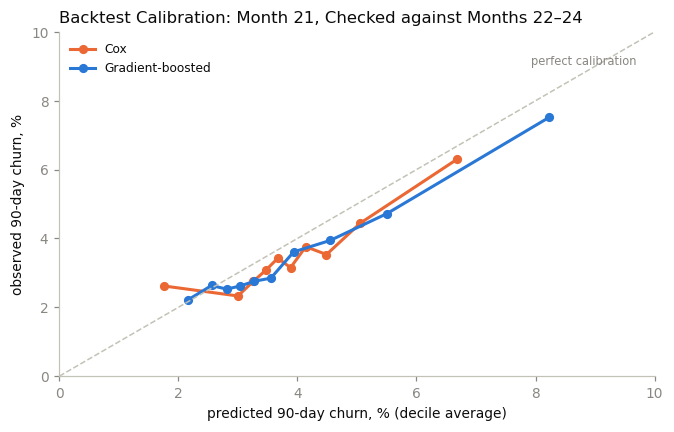

In [11]:
# Plot: Backtest Calibration by Risk Decile
months_back = scored_back['account_id'].map(leave_back)
fig, ax = plt.subplots(figsize = (6.2, 4))
for (name, probabilities), color in zip(list(backtest_probabilities.items())[1:], [ACCENT2, ACCENT]):
    frame = pd.DataFrame({'predicted': probabilities['p_churn_90'].to_numpy(), 'observed': (months_back <= 3).to_numpy()})
    frame['decile'] = pd.qcut(frame['predicted'].rank(method = 'first'), 10, labels = False)
    by_decile = frame.groupby('decile')[['predicted', 'observed']].mean() * 100
    ax.plot(by_decile['predicted'], by_decile['observed'], marker = 'o', markersize = 5, color = color, linewidth = 2, label = name)
limit = 10
ax.plot([0, limit], [0, limit], color = BASELINE, linewidth = 1, linestyle = '--')
ax.text(limit * 0.97, limit * 0.93, 'perfect calibration', ha = 'right', va = 'top', fontsize = 7.5, color = MUTED)
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel('predicted 90-day churn, % (decile average)')
ax.set_ylabel('observed 90-day churn, %')
ax.set_title('Backtest Calibration: Month 21, Checked against Months 22–24', loc = 'left')
ax.legend(frameon = False, fontsize = 8, loc = 'upper left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · Tonight's Batch</h2>
<p><strong>Purpose:</strong> Scores the 75,301 accounts active at the end of month 24, the batch the optimizer and agent act on, and then, from the answer key, measures how much of each account's true risk the models recover.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Final Fit.</strong> Both models refitted on the last 12 labeled months, months 12–23 (labels through month 24).</li>
<li style="margin-bottom: 0.7em;"><strong>Answer-Key Scoring.</strong> Two comparisons, each loaded only here: the realized months 25–27, and each account's true probability of leaving within 90 days with no offer. The true probability is also scored as if it were a model, which sets the ceiling: even perfect knowledge of each customer's risk can't predict who leaves exactly.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The model recovers part of the true risk.</strong> C-index 0.612 for the gradient-boosted model against 0.746 for the true probabilities, and a correlation of 0.39 with them. Most of the gap is hidden frailty, how inclined each customer is to leave, which no field in the data reveals.</li>
<li style="margin-bottom: 0.7em;"><strong>Its level is close.</strong> 3.8% predicted 90-day churn against 4.3% true and 4.2% observed over months 25–27, slightly low because the competitor promotion that starts in month 27 isn't in the data yet. In the top decile: 8.0% predicted, 8.3% true, 8.3% observed.</li>
<li style="margin-bottom: 0.7em;"><strong>Risk ranking reaches only some of the leavers.</strong> Contacting the riskiest 20% by the model would reach 34% of the customers who left in months 25–27; ranking by the true probabilities would reach 53%. And reaching a leaver isn't keeping one: whether an offer would change the outcome is section 02's question.</li>
</ol>
</div>

In [12]:
# Score Tonight's Batch
tonight = account_months[account_months['month'] == N_MONTHS]
scores = {'Cox': cox_probabilities(cox, tonight), 'Gradient-boosted': gbm_probabilities(gbm, tonight)}
print(f'{len(tonight):,} accounts scored · mean predicted 90-day churn: '
      + ' · '.join(f'{n} {p["p_churn_90"].mean():.2%}' for n, p in scores.items()))

75,301 accounts scored · mean predicted 90-day churn: Cox 3.76% · Gradient-boosted 3.83%


In [13]:
# Score against the Answer Key
truth = data.load_answer_key('truth_potential_outcomes').set_index('account_id')
future = data.load_answer_key('future_panel')
leave_future = months_to_leave(future, N_MONTHS)
true_p90 = truth.loc[tonight['account_id'], 'p_churn_90_control'].to_numpy()

rows = []
for name, probabilities in scores.items():
    result = evaluate(name, probabilities, tonight, leave_future)
    result['correlation with true 90-day risk'] = np.corrcoef(probabilities['p_churn_90'], true_p90)[0, 1]
    rows.append(result)
months_future = tonight['account_id'].map(leave_future)
rows.append({'model': 'True probability (ceiling)',
             'C-index': concordance_index(months_future.fillna(3.5), -true_p90, months_future.notna()),
             'AUC 90d': roc_auc_score((months_future <= 3).astype(int), true_p90),
             'Brier 90d': brier_score_loss((months_future <= 3).astype(int), true_p90),
             'predicted 90d': true_p90.mean(), 'observed 90d': (months_future <= 3).mean()})
final = pd.DataFrame(rows).set_index('model')
display(final[['C-index', 'AUC 90d', 'Brier 90d', 'predicted 90d', 'observed 90d', 'correlation with true 90-day risk']].T.style.format('{:.3f}', na_rep = '–'))

model,Cox,Gradient-boosted,True probability (ceiling)
C-index,0.582,0.612,0.746
AUC 90d,0.582,0.613,0.749
Brier 90d,0.040,0.040,0.038
predicted 90d,0.038,0.038,0.043
observed 90d,0.042,0.042,0.042
correlation with true 90-day risk,0.261,0.386,–


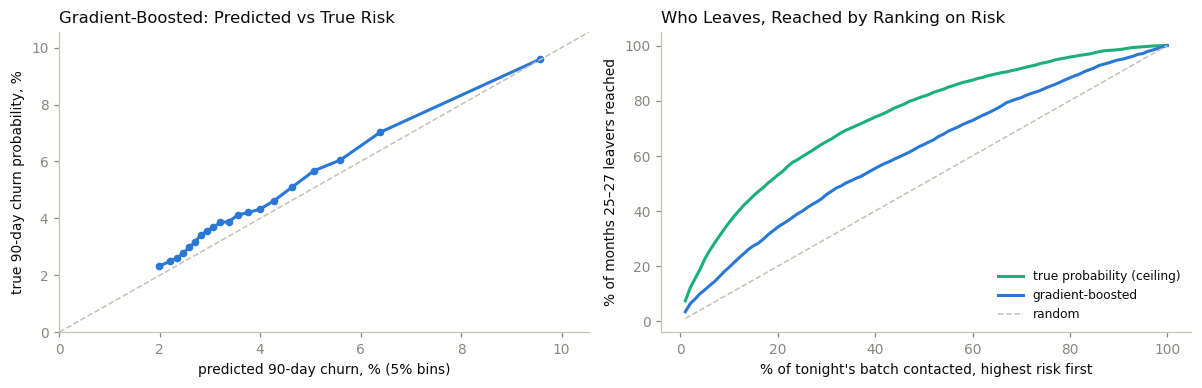

In [14]:
# Plot: Predicted vs True 90-Day Risk
fig, axes = plt.subplots(1, 2, figsize = (11, 3.6))
gbm_p90 = scores['Gradient-boosted']['p_churn_90'].to_numpy()
frame = pd.DataFrame({'predicted': gbm_p90 * 100, 'true': true_p90 * 100})
frame['bin'] = pd.qcut(frame['predicted'].rank(method = 'first'), 20, labels = False)
by_bin = frame.groupby('bin').mean()
axes[0].plot(by_bin['predicted'], by_bin['true'], marker = 'o', markersize = 4, color = ACCENT, linewidth = 2)
limit = max(by_bin.max()) * 1.1
axes[0].plot([0, limit], [0, limit], color = BASELINE, linewidth = 1, linestyle = '--')
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel('predicted 90-day churn, % (5% bins)')
axes[0].set_ylabel('true 90-day churn probability, %')
axes[0].set_title('Gradient-Boosted: Predicted vs True Risk', loc = 'left')

shares = np.arange(1, 101)
order_model = np.argsort(-gbm_p90)
order_true = np.argsort(-true_p90)
leavers = (months_future <= 3).to_numpy()
captured = lambda order: [leavers[order[: int(len(order) * s / 100)]].sum() / leavers.sum() * 100 for s in shares]
axes[1].plot(shares, captured(order_true), color = TEAL, linewidth = 2, label = 'true probability (ceiling)')
axes[1].plot(shares, captured(order_model), color = ACCENT, linewidth = 2, label = 'gradient-boosted')
axes[1].plot(shares, shares, color = BASELINE, linewidth = 1, linestyle = '--', label = 'random')
axes[1].set_xlabel('% of tonight\'s batch contacted, highest risk first')
axes[1].set_ylabel('% of months 25–27 leavers reached')
axes[1].set_title('Who Leaves, Reached by Ranking on Risk', loc = 'left')
axes[1].legend(frameon = False, fontsize = 8, loc = 'lower right')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>6 · Handoff</h2>
<p><strong>Purpose:</strong> Saves tonight's churn probabilities for the optimizer (section 04) and the agent, and the training months' out-of-sample risk for the uplift model (section 02).</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model Used Downstream.</strong> The gradient-boosted model, which ranks and calibrates better on the backtest (section 4).</li>
<li style="margin-bottom: 0.7em;"><strong>Files.</strong> <code>outputs/</code> is not tracked; rerunning this notebook regenerates it.</li>
</ol>
</div>

In [15]:
# Save Churn Scores
churn_scores = pd.concat([tonight[['account_id']], scores['Gradient-boosted']], axis = 1)
print(save_output(churn_scores, 'churn_scores'), f'· {len(churn_scores):,} accounts')

campaign_1_scores = account_months[account_months['month'] == 13].merge(
    campaigns.loc[campaigns['campaign'] == 'campaign_1', ['account_id']], on = 'account_id')
campaign_1_scores = pd.concat([campaign_1_scores[['account_id']], gbm_probabilities(fit_gbm(training_window(12)), campaign_1_scores)], axis = 1)
print(save_output(campaign_1_scores, 'campaign_1_churn_scores'), f'· {len(campaign_1_scores):,} accounts, scored with a model fitted on months 1–12')

outputs/churn_scores.parquet · 75,301 accounts


outputs/campaign_1_churn_scores.parquet · 40,000 accounts, scored with a model fitted on months 1–12


<hr>
<div>
<h2>Section 01 Summary</h2>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Risk is partly predictable.</strong> The gradient-boosted hazard ranks tonight's accounts with a C-index of 0.61, against 0.75 for the true probabilities; the rest depends on how inclined each customer is to leave, which the carrier can't see.</li>
<li style="margin-bottom: 0.7em;"><strong>The drivers are concrete.</strong> A phone just paid off, a move, competitor promotions, dropped calls, and early tenure.</li>
<li style="margin-bottom: 0.7em;"><strong>Levels drift.</strong> A model fitted through a competitor surge over-predicted the quiet months after it by about 15%; the ranking held. Monitoring predicted against actual churn is part of running it.</li>
<li style="margin-bottom: 0.7em;"><strong>Risk alone is not the decision.</strong> The riskiest fifth of the base holds about a third of the customers who leave, and says nothing about which of them an offer would keep. Section 02 estimates that.</li>
</ol>
</div>